<a href="https://colab.research.google.com/github/ManasaRaparthi/OIBSIP/blob/main/OasisTask4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Email Spam Detection using Machine Learning

Spam emails are unwanted messages sent to a large number of users.
These emails often contain advertisements, scams, or phishing links.

In this project, we build a machine learning model to classify emails
as spam or not spam using Natural Language Processing techniques.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.naive_bayes import MultinomialNB

In [ ]:
df = pd.read_csv("spam.csv", encoding='latin-1')

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [ ]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

df.info()

Dataset Shape: (5572, 5)

Column Names:
Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [ ]:
df = df[['v1','v2']]

In [ ]:
df.columns = ['Label','Message']

df.head()

,Label,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df['Label'] = df['Label'].map({'ham':0,'spam':1})

In [ ]:
df['Label'].value_counts()

,count
Label,
0,4825
1,747


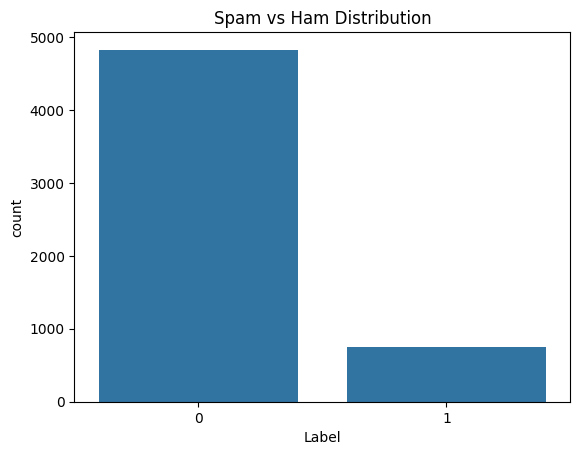

In [ ]:
sns.countplot(x='Label', data=df)

plt.title("Spam vs Ham Distribution")

plt.show()

In [ ]:
vectorizer = CountVectorizer()

X = vectorizer.fit_transform(df['Message'])
y = df['Label']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.97847533632287


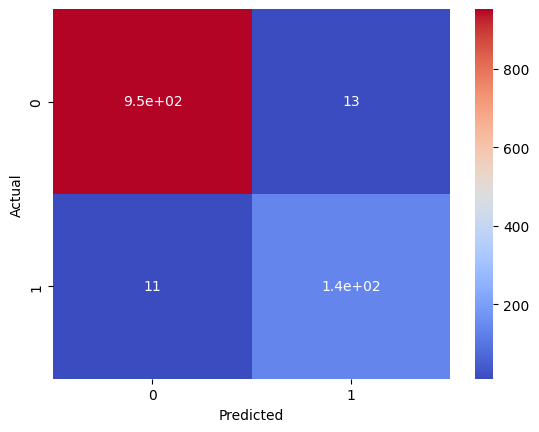

In [ ]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, cmap="coolwarm")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       965
           1       0.91      0.93      0.92       150

    accuracy                           0.98      1115
   macro avg       0.95      0.96      0.95      1115
weighted avg       0.98      0.98      0.98      1115



In [ ]:
sample_email = ["Congratulations! You have won a free lottery ticket"]

sample_vector = vectorizer.transform(sample_email)

prediction = model.predict(sample_vector)

if prediction[0] == 1:
    print("This email is Spam")
else:
    print("This email is Not Spam")

This email is Spam


## Key Insights

1. Spam emails can be detected using machine learning models.
2. Text data must be converted into numerical features using vectorization.
3. The Naive Bayes algorithm performs well for text classification problems.
4. The model achieved high accuracy in distinguishing spam from legitimate emails.

In this project, a machine learning model was built to classify emails
as spam or not spam using Natural Language Processing techniques.
The dataset was preprocessed and converted into numerical features
using CountVectorizer. A Multinomial Naive Bayes model was trained
to classify the messages.

The model achieved high accuracy in detecting spam emails. This
demonstrates how machine learning can effectively be used to filter
spam messages and improve email security.